In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

### Estructura de la Red
*   **Entradas ($X$):** 2 entradas (representando los 2 bits).
*   **Salidas ($y$):** 2 neuronas.
    *   Neurona 1: Aprenderá la lógica **AND**.
    *   Neurona 2: Aprenderá la lógica **OR**.
*   **Bias ($b$):** Un valor de sesgo independiente para cada neurona de salida.

### Fórmulas Matemáticas Clave

#### Función de Activación (Escalón)
Usamos la función escalón para binarizar la salida (0 o 1).
$$ 
f(z) = \begin{cases} 
1 & \text{si } z \geq 0 \\
0 & \text{si } z < 0 
\end{cases}
$$

#### Cálculo de la Salida (Predicción)
Para cada neurona de salida $j$ (donde $j=0$ es AND, $j=1$ es OR), la salida se calcula como la suma ponderada de las entradas más el bias específico, pasada por la función de activación:
$$ z_j = \sum_{i=1}^{n} (x_i \cdot w_{ij}) + b_j $$
$$ \hat{y}_j = f(z_j) $$

Donde:
*   $x_i$: Entrada $i$.
*   $w_{ij}$: Peso que conecta la entrada $i$ con la neurona de salida $j$.
*   $b_j$: Bias de la neurona de salida $j$.

#### Regla de Aprendizaje (Actualización de Pesos)
Los pesos se actualizan iterativamente para reducir el error de cada neurona de salida independientemente:
$$ w_{ij}(t+1) = w_{ij}(t) + \eta \cdot (y_j - \hat{y}_j) \cdot x_i $$
$$ b_j(t+1) = b_j(t) + \eta \cdot (y_j - \hat{y}_j) $$

Donde:
*   $\eta$ (eta): Tasa de aprendizaje (Learning Rate).
*   $(y_j - \hat{y}_j)$: Error específico de la neurona $j$ (Salida Esperada - Salida Predicha).

In [9]:
#Función de activación escalon
def step_function(x):
    return np.where(x >= 0, 1, 0)

#Función de predicción del perceptrón
def perceptron_predict(X, weights):
    return step_function(np.dot(X, weights[1:]) + weights[0])

# Algoritmo del Perceptrón
def perceptron_train(X, y, learning_rate=0.1, epochs=10):
    n_features = X.shape[1] #Número de características 
    n_outputs = y.shape[1] # Número de neuronas de salida
    
    # Inicializar matriz de pesos (n_features + 1 filas, n_outputs columnas)
    weights = np.random.rand(n_features + 1, n_outputs)
    errors = []

    for _ in range(epochs):
        total_error = 0
        for xi, target in zip(X, y):
            #Predicción
            output = perceptron_predict(xi, weights)
            
            # Calculo error
            error = target - output
            total_error += np.sum(np.abs(error)) # Suma de errores de todas las salidas

            # Actualizar pesos
            # Bias: se actualiza con learning_rate * error
            weights[0] += learning_rate * error
            # Pesos de entradas (filas 1 a n): producto externo de entrada x error
            weights[1:] += learning_rate * np.outer(xi, error)
            
        errors.append(total_error)
    return weights, errors

### Definición del Dataset

Definimos las 4 posibles combinaciones de 2 bits ($2^2=4$) y sus salidas correspondientes para las compuertas:
1.  **AND (2 inputs):** Salida es 1 solo si ambas entradas son 1.
2.  **OR (2 inputs):** Salida es 1 si almenos una entrada es 1.

In [10]:
# ---Preparación de Datos (2 Entradas, 2 Salidas) ---
# Entradas (2 bits)
X = np.array([
    [0, 0], [0, 1],
    [1, 0], [1, 1]
])

# Salidas esperadas:
# Columna 0: AND
# Columna 1: OR
y = np.array([
    [0, 0], # 00 -> AND=0, OR=0
    [0, 1], # 01 -> AND=0, OR=1
    [0, 1], # 10 -> AND=0, OR=1
    [1, 1]  # 11 -> AND=1, OR=1
])

print("Entradas X:\n", X)
print("\nSalidas Esperadas Y (Col0=AND, Col1=OR):\n", y)

Entradas X:
 [[0 0]
 [0 1]
 [1 0]
 [1 1]]

Salidas Esperadas Y (Col0=AND, Col1=OR):
 [[0 0]
 [0 1]
 [0 1]
 [1 1]]


### Proceso de Entrenamiento

El algoritmo iterará la cantidad de epocas definidas sobre todo el conjunto de datos. En cada paso:
1.  Calculará la predicción actual.
2.  Comparará con la salida real.
3.  Ajustará los pesos proporcionalmente al error cometido.

Si la convergencia es exitosa, el error debería llegar a 0 (o muy cerca).

In [11]:
# --- Entrenamiento de la Red ---

weights, errors = perceptron_train(X, y, learning_rate=0.1, epochs=20)

print("Entrenamiento completado.")
print("Matriz de Pesos Finales:\n", weights)

Entrenamiento completado.
Matriz de Pesos Finales:
 [[-0.36933092 -0.07708559]
 [ 0.24226587  0.40731341]
 [ 0.21583971  0.78924386]]


In [12]:
# --- Validación / Predicciones ---
print("\n--- Validación del Modelo ---")
print(f"{'Entrada (X)':<15} | {'Esperado (AND/OR)':<18} | {'Predicción (AND/OR)':<20} | {'¿Correcto?'}")
print("-" * 70)

aciertos = 0
for i, xi in enumerate(X):
    prediction = perceptron_predict(xi, weights)
    target = y[i]
    
    es_correcto = np.array_equal(prediction, target)
    if es_correcto: aciertos += 1
    
    print(f"{str(xi):<15} | {str(target):<18} | {str(prediction):<20} | {'Si' if es_correcto else 'No'}")

print("-" * 70)
print(f"Precisión Total: {aciertos}/{len(X)} ({(aciertos/len(X))*100:.1f}%)")


--- Validación del Modelo ---
Entrada (X)     | Esperado (AND/OR)  | Predicción (AND/OR)  | ¿Correcto?
----------------------------------------------------------------------
[0 0]           | [0 0]              | [0 0]                | Si
[0 1]           | [0 1]              | [0 1]                | Si
[1 0]           | [0 1]              | [0 1]                | Si
[1 1]           | [1 1]              | [1 1]                | Si
----------------------------------------------------------------------
Precisión Total: 4/4 (100.0%)


### Visualización de la Convergencia

Grafica el error global acumulado en cada época. 
*   Un gráfico descendente indica que la red está aprendiendo correctamente.
*   Llegar a 0 significa que la red ha aprendido perfectamente a separar linealmente todas las clases.

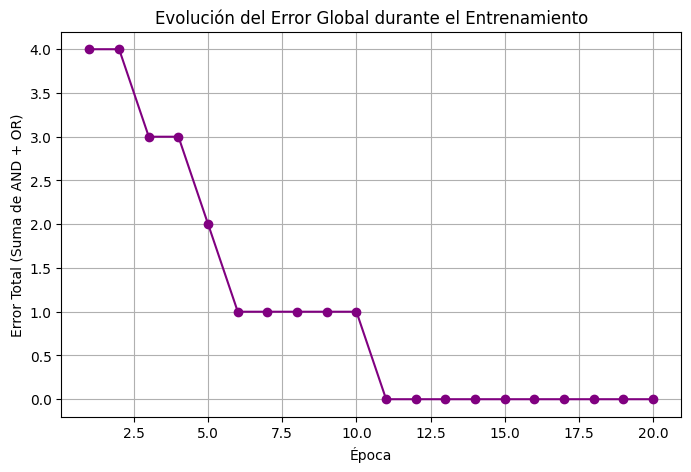

In [13]:
# --- Gráfica de Error Global ---
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(errors) + 1), errors, marker='o', color='purple')
plt.xlabel('Época')
plt.ylabel('Error Total (Suma de AND + OR)')
plt.title('Evolución del Error Global durante el Entrenamiento')
plt.grid(True)
plt.show()

### Visualización 2D: Recta de Decisión

Dado que tenemos 2 entradas ($x_1, x_2$), el espacio de entrada es bidimensional.
El Perceptrón aprende una recta de separación definida por la ecuación:

$$ w_1 \cdot x_1 + w_2 \cdot x_2 + b = 0 $$

Despejando para $x_2$:
$$ x_2 = -\frac{x_1 \cdot w_1 + b}{w_2} $$

Visualizamos esa recta cortando el plano.
*   **Puntos Rojos/Azules:** Datos de entrenamiento.
*   **Línea Cian:** Frontera de decisión aprendida. Los puntos a un lado de la recta se clasifican como 0 y al otro como 1.

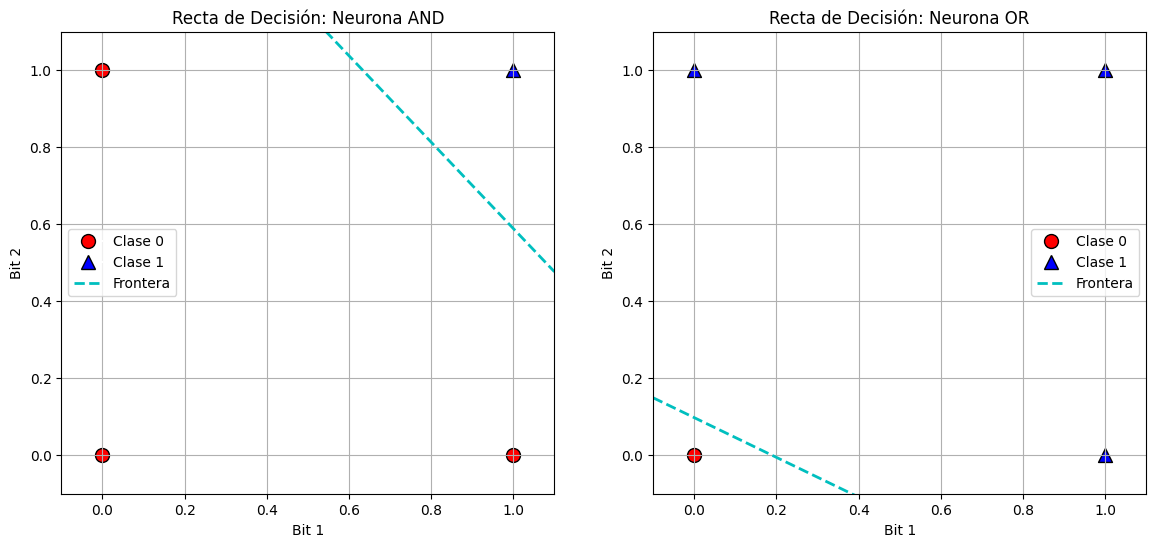

In [14]:
    
# Visualización 2D de Rectas de Decisión ---

def plot_decision_boundary_2d(X, y_target, single_weights, title, ax):
    # Graficar puntos de datos
    for i, xi in enumerate(X):
        # y_target[i] es escalar (0 o 1) para esta neurona específica
        color = 'red' if y_target[i] == 0 else 'blue'
        marker = 'o' if y_target[i] == 0 else '^'
        ax.scatter(xi[0], xi[1], c=color, marker=marker, s=100, edgecolors='k')

    # Recta de decision: w1*x1 + w2*x2 + w0 = 0 -> x2 = -(w1*x1 + w0)/w2
    w0, w1, w2 = single_weights[0], single_weights[1], single_weights[2]
    
    x_min, x_max = -0.1, 1.1
    xx = np.linspace(x_min, x_max, 100)
    
    if abs(w2) > 1e-5:
        yy = (-w1 * xx - w0) / w2
        ax.plot(xx, yy, 'c--', linewidth=2, label='Frontera de Decisión')
    else:
        ax.axvline(x=-w0/w1, color='c', linestyle='--', linewidth=2, label='Frontera Vertical')
    
    ax.set_xlabel('Bit 1')
    ax.set_ylabel('Bit 2')
    ax.set_title(title)
    ax.set_xlim(-0.1, 1.1)
    ax.set_ylim(-0.1, 1.1)
    ax.grid(True)
    
    
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='red', label='Clase 0', markersize=10, markeredgecolor='k'),
        Line2D([0], [0], marker='^', color='w', markerfacecolor='blue', label='Clase 1', markersize=10, markeredgecolor='k'),
        Line2D([0], [0], color='c', lw=2, linestyle='--', label='Frontera')
    ]
    ax.legend(handles=legend_elements)

# --- GRÁFICA 1: Neurona AND ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

weights_and = weights[:, 0] # Columna 0
plot_decision_boundary_2d(X, y[:, 0], weights_and, "Recta de Decisión: Neurona AND", axes[0])

# --- GRÁFICA 2: Neurona OR ---
weights_or = weights[:, 1]  # Columna 1
plot_decision_boundary_2d(X, y[:, 1], weights_or, "Recta de Decisión: Neurona OR", axes[1])

plt.show()